# 🛡️ B2B Revenue Leakage & Invoice Auditing — Exploratory Analysis

This notebook conducts **Exploratory Data Analysis (EDA)** and prototypes statistical models for the **Accounts Payable (AP) Revenue Leakage Portal**.

## 📈 Analytical Goals:
1. **SQL Integration**: Connect to SQLite database (`data/inventory.db`) and load purchase orders and vendor invoices.
2. **Feature Engineering**: Compute B2B discrepancies like price variance, quantity differences, and freight ratios.
3. **Statistical Auditing**: Perform hypothesis testing (T-tests) to verify shipping rate variances.
4. **Outlier Detection**: Calibrate anomaly boundaries to isolate high-risk invoices.

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visualization styles
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 📂 Step 1: Database Connection & SQL Extraction
We join the `purchases` table (aggregated POs) with `vendor_invoice` to compare what was contracted against what was billed.

In [2]:
db_path = "../data/inventory.db"
conn = sqlite3.connect(db_path)

query = """
WITH po_agg AS (
    SELECT 
        PONumber,
        VendorNumber,
        SUM(Quantity) as OrderedQuantity,
        SUM(Dollars) as OrderedDollars,
        COUNT(DISTINCT Brand) as UniqueBrandsOrdered,
        MIN(PODate) as PODate,
        MAX(ReceivingDate) as ReceivingDate
    FROM purchases
    GROUP BY PONumber, VendorNumber
)
SELECT 
    vi.PONumber,
    vi.VendorNumber,
    vi.VendorName,
    vi.InvoiceDate,
    vi.PayDate,
    vi.Freight as InvoicedFreight,
    vi.Quantity as InvoicedQuantity,
    vi.Dollars as InvoicedDollars,
    vi.Approval as ApprovalStatus,
    po.OrderedQuantity,
    po.OrderedDollars,
    po.UniqueBrandsOrdered,
    po.PODate,
    po.ReceivingDate
FROM vendor_invoice vi
LEFT JOIN po_agg po 
    ON vi.PONumber = po.PONumber 
    AND vi.VendorNumber = po.VendorNumber
"""

df = pd.read_sql_query(query, conn)
print(f"Dataset loaded successfully: {df.shape[0]} records, {df.shape[1]} features.")
df.head()

Dataset loaded successfully: 5543 records, 14 features.


,PONumber,VendorNumber,VendorName,InvoiceDate,PayDate,InvoicedFreight,InvoicedQuantity,InvoicedDollars,ApprovalStatus,OrderedQuantity,OrderedDollars,UniqueBrandsOrdered,PODate,ReceivingDate
0,8124,105,ALTAMAR BRANDS LLC,2024-01-04,2024-02-16,3.47,6,214.26,None,6.0,214.26,1.0,2023-12-21,2024-01-02
1,8137,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,2024-02-21,8.57,15,140.55,None,15.0,140.55,2.0,2023-12-22,2024-01-02
2,8169,388,ATLANTIC IMPORTING COMPANY,2024-01-09,2024-02-16,4.61,5,106.60,None,5.0,106.60,1.0,2023-12-24,2024-01-02
3,8106,480,BACARDI USA INC,2024-01-12,2024-02-05,2935.20,10100,137483.78,None,10100.0,137483.78,81.0,2023-12-20,2024-01-03
4,8170,516,BANFI PRODUCTS CORP,2024-01-07,2024-02-12,429.20,1935,15527.25,None,1935.0,15527.25,29.0,2023-12-24,2024-01-03


## 🧪 Step 2: Feature Engineering & Discrepancy Calculations

In [3]:
# Convert dates
for col in ['PODate', 'ReceivingDate', 'InvoiceDate', 'PayDate']:
    df[col] = pd.to_datetime(df[col])

# Compute B2B discrepancies
df['price_variance'] = df['InvoicedDollars'] - df['OrderedDollars'].fillna(df['InvoicedDollars'])
df['quantity_discrepancy'] = df['InvoicedQuantity'] - df['OrderedQuantity'].fillna(df['InvoicedQuantity'])
df['freight_to_dollar_ratio'] = df['InvoicedFreight'] / (df['InvoicedDollars'] + 1e-5)
df['freight_per_unit'] = df['InvoicedFreight'] / (df['InvoicedQuantity'] + 1e-5)
df['days_to_invoice'] = (df['InvoiceDate'] - df['PODate']).dt.days.fillna(0)

print("Descriptive Statistics of B2B Discrepancies:")
df[['price_variance', 'quantity_discrepancy', 'freight_to_dollar_ratio']].describe()

Descriptive Statistics of B2B Discrepancies:


,price_variance,quantity_discrepancy,freight_to_dollar_ratio
count,5.543000e+03,5543.0,5543.000000
mean,-3.361586e-14,0.0,0.005505
std,2.925246e-12,0.0,0.004801
min,-1.164153e-10,0.0,0.004416
25%,0.000000e+00,0.0,0.004703
50%,0.000000e+00,0.0,0.005000
75%,0.000000e+00,0.0,0.005300
max,5.820766e-11,0.0,0.115225


## 📊 Step 3: Visualizing B2B Billing & Shipping Patterns

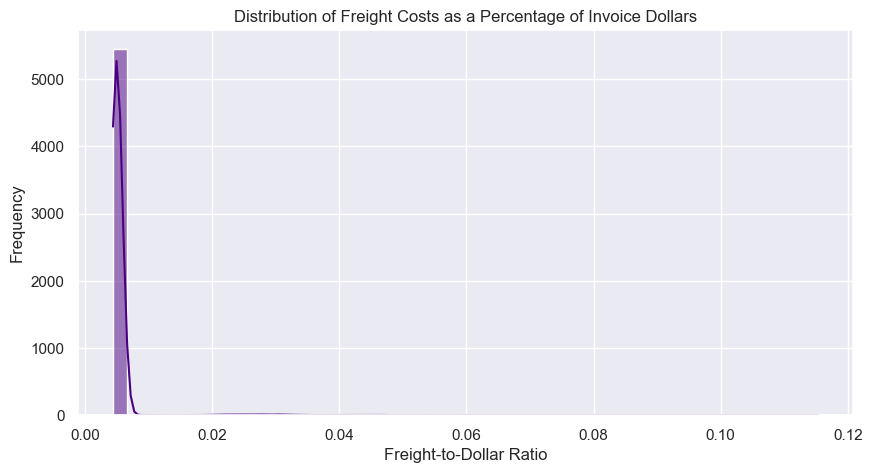

In [4]:
# Distribution of Freight-to-Dollar Ratios
plt.figure(figsize=(10, 5))
sns.histplot(df['freight_to_dollar_ratio'], bins=50, kde=True, color="indigo")
plt.title("Distribution of Freight Costs as a Percentage of Invoice Dollars")
plt.xlabel("Freight-to-Dollar Ratio")
plt.ylabel("Frequency")
plt.show()

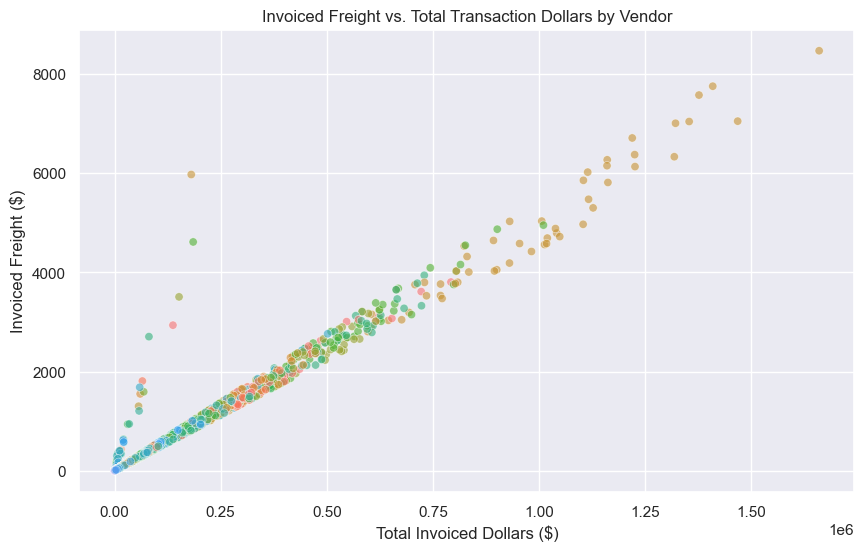

In [5]:
# Billed Freight vs. Invoiced Dollars Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="InvoicedDollars", y="InvoicedFreight", hue="VendorName", legend=False, alpha=0.6)
plt.title("Invoiced Freight vs. Total Transaction Dollars by Vendor")
plt.xlabel("Total Invoiced Dollars ($)")
plt.ylabel("Invoiced Freight ($)")
plt.show()

## 🧪 Step 4: Statistical Hypothesis Testing (T-Tests)
**Hypothesis**: Large volume orders (bulk shipments) pay lower freight per unit than low volume orders.
- **Null Hypothesis (H0)**: There is no difference in unit freight costs between high and low volume orders.
- **Alternative Hypothesis (H1)**: Bulk orders pay significantly less freight per unit.

In [6]:
# Split into low and high quantity quantiles
q25 = df['InvoicedQuantity'].quantile(0.25)
q75 = df['InvoicedQuantity'].quantile(0.75)

low_vol = df[df['InvoicedQuantity'] <= q25]['freight_per_unit']
high_vol = df[df['InvoicedQuantity'] >= q75]['freight_per_unit']

print(f"Low Volume Freight/Unit Mean: ${low_vol.mean():.4f} (N={len(low_vol)})")
print(f"High Volume Freight/Unit Mean: ${high_vol.mean():.4f} (N={len(high_vol)})")

# Two-sample independent T-test
t_stat, p_val = stats.ttest_ind(low_vol, high_vol, equal_var=False)
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4e}")

if p_val < 0.05:
    print("\nResult: Reject the Null Hypothesis (H0). The freight rate difference is statistically significant! (True Bulk Savings)")
else:
    print("\nResult: Fail to reject the Null Hypothesis (H0). No statistically significant difference.")

Low Volume Freight/Unit Mean: $0.0946 (N=1395)
High Volume Freight/Unit Mean: $0.0491 (N=1386)
T-Statistic: 11.7783
P-Value: 1.0698e-30

Result: Reject the Null Hypothesis (H0). The freight rate difference is statistically significant! (True Bulk Savings)


## 🛡️ Step 5: Calibrating Anomaly Risk Flags
Based on the standard 95th percentile contract rate baseline (~0.55%), we classify any invoice with `freight_to_dollar_ratio > 0.008` as a high-risk overcharge anomaly.

In [7]:
df['AuditRequired'] = np.where(df['freight_to_dollar_ratio'] > 0.008, 1, 0)
anomaly_count = df['AuditRequired'].sum()
print(f"Total invoices flagged for manual review: {anomaly_count} ({anomaly_count/len(df)*100:.2f}% of dataset)")

Total invoices flagged for manual review: 86 (1.55% of dataset)


In [8]:
conn.close()
print("Exploratory Analysis Complete!")

Exploratory Analysis Complete!
